In [1]:
import pandas as pd

## Do some EDA on behaviors dataset first

In [2]:
df_behavior = pd.read_parquet('data/behaviors.parquet')

In [3]:
df_behavior

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...
...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...
156961,156962,U10123,11/13/2019 6:57:04 AM,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...
156962,156963,U75630,11/14/2019 10:58:13 AM,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...
156963,156964,U44625,11/13/2019 2:57:02 PM,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...


In [4]:
# 1. Count items in history (space-separated IDs)

df_behavior['history_cnt'] = df_behavior['history'].str.split().str.len()

# 2. Extract click/no-click counts from impressions
# Split impressions into individual items, then count based on the suffix
df_behavior['impressions_click'] = df_behavior['impressions'].str.split().apply(
    lambda x: sum(1 for item in x if item.split('-')[1] == '1')
)
df_behavior['impressions_noclick'] = df_behavior['impressions'].str.split().apply(
    lambda x: sum(1 for item in x if item.split('-')[1] == '0')
)


In [5]:
df_behavior

,impression_id,user_id,time,history,impressions,history_cnt,impressions_click,impressions_noclick
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0,9.0,1,1
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,82.0,1,10
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,16.0,1,35
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0,10.0,1,3
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,4.0,1,68
...,...,...,...,...,...,...,...,...
156960,156961,U21593,11/14/2019 10:24:05 PM,N7432 N58559 N1954 N43353 N14343 N13008 N28833...,N2235-0 N22975-0 N64037-0 N47652-0 N11378-0 N4...,62.0,1,30
156961,156962,U10123,11/13/2019 6:57:04 AM,N9803 N104 N24462 N57318 N55743 N40526 N31726 ...,N3841-0 N61571-0 N58813-0 N28213-0 N4428-0 N25...,32.0,1,88
156962,156963,U75630,11/14/2019 10:58:13 AM,N29898 N59704 N4408 N9803 N53644 N26103 N812 N...,N55913-0 N62318-0 N53515-0 N10960-0 N9135-0 N5...,23.0,1,42
156963,156964,U44625,11/13/2019 2:57:02 PM,N4118 N47297 N3164 N43295 N6056 N38747 N42973 ...,N6219-0 N3663-0 N31147-0 N58363-0 N4107-0 N457...,58.0,5,114


<Axes: ylabel='Frequency'>

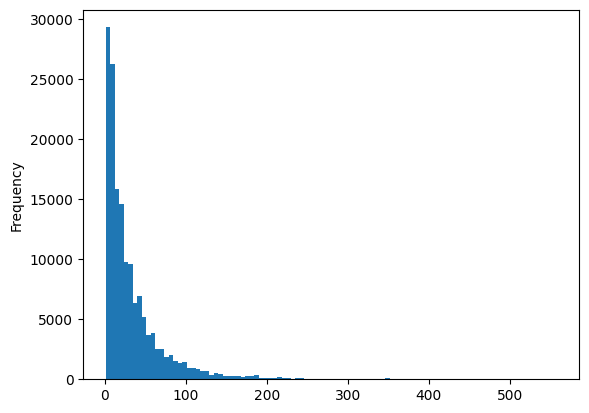

In [9]:
df_behavior['history_cnt'].plot(kind='hist',bins=100)

In [12]:
df_behavior['impressions_noclick'].describe()

count    156965.000000
mean         35.721976
std          38.149210
min           1.000000
25%           9.000000
50%          23.000000
75%          49.000000
max         297.000000
Name: impressions_noclick, dtype: float64

In [11]:
df_behavior['impressions_click'].describe()

count    156965.000000
mean          1.505711
std           1.153102
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          35.000000
Name: impressions_click, dtype: float64